Plot SOLPS balance file

In [2]:
##### %matplotlib widget


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, sys, pathlib, shlex, subprocess
# import xbout
import scipy
import netCDF4 

import xhermes
# from xhermes import *
sys.path.append(r"/Users/zero/workspace/phd_work/hms_output/sdtools/")
sys.path.append(r"/Users/zero/workspace/phd_work/hms_output/hermes3-2dplots/pltool")
from code_comparison.solps_pp import *
from hermes3.case_db import *
from hermes3.load import *
from hermes3.named_selections import *
from hermes3.plotting import *
from hermes3.grid_fields import *
from hermes3.accessors import *
from hermes3.utils import *

from common import setup_matplotlib, format_legend_and_axes

%load_ext autoreload
%autoreload 2
print("Loaded")


Loaded


#### Check variables by reading netcdf

In [31]:
## Checkv variables by netcdf
filepath = "./balance.nc"
nc = netCDF4.Dataset(filepath)
list(nc.variables.keys() )
# key = "pr"
# if key in nc.variables.keys():
#     print(key)
#     print(nc[key])
# else:
#     print("Not found")
# import xarray as xr


# import netCDF4

# filepath = "./balance.nc"
# nc = netCDF4.Dataset(filepath)

# for var_name in nc.variables:
#     var = nc.variables[var_name]
#     # 'long_name' is the standard NetCDF attribute for descriptions
#     description = getattr(var, 'long_name', 'No description available')
#     units = getattr(var, 'units', 'no units')
    
#     print(f"Variable: {var_name}")
#     print(f"  Description: {description}")
#     print(f"  Units: {units}\n")


['crx',
 'cry',
 'bb',
 'hx',
 'hy',
 'hz',
 'vol',
 'gs',
 'am',
 'mp',
 'ev',
 'leftix',
 'leftiy',
 'rightix',
 'rightiy',
 'topix',
 'topiy',
 'bottomix',
 'bottomiy',
 'jxi',
 'jxa',
 'jsep',
 'species',
 'b2mndr_eirene',
 'b2mndr_hz',
 'za',
 'fna_pinch',
 'fna_pll',
 'fna_drift',
 'fna_ch',
 'fna_nanom',
 'fna_panom',
 'fna_pschused',
 'fna_tot',
 'b2stbr_phys_sna_bal',
 'b2stbr_bas_sna_bal',
 'b2stbr_first_flight_sna_bal',
 'b2stbc_sna_bal',
 'b2stbm_sna_bal',
 'ext_sna_bal',
 'b2stel_sna_ion_bal',
 'b2stel_sna_rec_bal',
 'b2stcx_sna_bal',
 'b2srsm_sna_bal',
 'b2srdt_sna_bal',
 'b2srst_sna_bal',
 'tot_sna_bal',
 'resco',
 'fmo_flua',
 'fmo_cvsa',
 'fmo_hybr',
 'fmo_b2nxfv',
 'fmo_tot',
 'b2stbr_phys_smo_bal',
 'b2stbr_bas_smo_bal',
 'b2stbc_smo_bal',
 'b2stbm_smo_bal',
 'ext_smo_bal',
 'b2stel_smq_ion_bal',
 'b2stel_smq_rec_bal',
 'b2stcx_smq_bal',
 'b2srsm_smo_bal',
 'b2srdt_smo_bal',
 'b2srst_smo_bal',
 'b2sifr_smoch_bal',
 'b2sifr_smotf_ehxp_bal',
 'b2sifr_smotf_cthe_bal',
 

## Read SOLPS by solps_pp and read hermes-3

In [6]:
# Read SOLPS
bal = SOLPScase(".")
# print(type(bal))

# Read Hermes-3
db = CaseDB(
    case_dir = r"/users/jpm590/scratch/",
    grid_dir = r"/users/jpm590/gridfile"
    # grid_dir = r"/users/jpm590/neutralrun/hermes-3/master"

)
toload = [
    dict(name="nowallpump_1e21_limiterOFF", id="260217-cdn-46895-nowallpump_limiterOff_1e21", unnormalise_geom = True, use_xhermes = True, squash = True),   
    # dict(name="nowallpump_1e21", id="260427_reproduce_1e21_neumann_nowallpump", unnormalise_geom = True, use_xhermes = True, squash = True),

]
cs = {}
for case in toload:
    cs[case["name"]] = db.load_case_2D(case["id"], use_squash = case["squash"], verbose = True)

    cs[case["name"]].extract_2d_tokamak_geometry()

/users/jpm590/workspace/hermes-3/venv/lib/python3.12/site-packages/boutdata/data.py:765: AlwaysWarning: While building x, y, z coordinate arrays, an exception occured: [Errno 2] No such file or directory: '"CDN_46895_260129_nowallpump_1e21.nc"'
Evaluating non-scalar options not available
  alwayswarn(


- Reading case 260217-cdn-46895-nowallpump_limiterOff_1e21
-----------------------
- Looking for squash file
- Squash file found. squash date 02/23/2026, 23:35:19, dmp file date 02/23/2026, 23:17:54
Lazily opening dataset at /users/jpm590/scratch/260217-cdn-46895-nowallpump_limiterOff_1e21


/users/jpm590/2dspace/post-processing/xBOUT/xbout/load.py:1203: UserWarning: Will drop all variables containing the dimensions 'closed_wall' because they are not recognised
  warn(



Unnormalising with xHermes


## Check some number between the two

In [22]:
# SOLPS
df = bal.get_1d_radial_data(params=["Td+","Nd+","Te","Ne",], region="omp")


# Hermes-3 
print("\n" + "="*50)
print("Hermes-3 Parameters")
print("="*50)

ds = cs["nowallpump_1e21_limiterOFF"].ds.isel(t=-1)

nparticle = (ds["Nd+"].values +
             ds["Nd"].values +
             ds["Ne"].values) * ds["dv"].values
nparticles = np.sum(nparticle)
nion= (ds["Nd+"].values  * ds["dv"].values)
nions = np.sum(nion)
ne= (ds["Ne"].values  * ds["dv"].values)
nes = np.sum(ne)

puff_rate = np.sum(ds["Sd_src"].values * ds["dv"].values)

extra_particles = nparticles - puff_rate

recycled_neutral = np.sum(
    ds["Sd_target_recycle"].values * ds["dv"].values
)
# print(ds["Sd_target_recycle"].values)
recomb = np.sum(
    ds["Sd+_rec"].values * ds["dv"].values
)
iz = np.sum(
    ds["Sd+_iz"].values * ds["dv"].values
)
ext_ion_src = np.sum(
    ds["Sd+_src"].values * ds["dv"].values
)

print(f"{'Total particles:':30s} {nparticles:15.6e}")
print(f"{'Total ions:':30s} {nions:15.6e}")
print(f"{'Total electrons:':30s} {nes:15.6e}")

print(f"{'Puff rate (Sd_src):':30s} {puff_rate:15.6e}")
print(f"{'Extra particles:':30s} {extra_particles:15.6e}")
print("-"*50)
print(f"{'Expected ion lost (1%):':30s} {puff_rate*0.01:15.6e}")
print(f"{'Expected n recycled (99%):':30s} {puff_rate*0.99:15.6e}")
print(f"{'Actual recycled neutrals:':30s} {recycled_neutral:15.6e}")
print("-"*50)
print("Total sink of ions")
#original ion flux into target recycled_neutral/0.99
lost_ion = recycled_neutral/0.99*0.01
print(f"{'Sd+_rec:':30s} {recomb:15.6e}")
print(f"{'ion lost:':30s} {lost_ion:15.6e}")

print("Total source of ions")
print(f"{'Sd+_iz:':30s} {iz:15.6e}")

# print(f"external ions {'Sd+_src':30s} {ext_ion_src:15.6e}")


print("="*50)



Hermes-3 Parameters
Total particles:                  1.210552e+21
Total ions:                       2.379774e+20
Total electrons:                  2.379774e+20
Puff rate (Sd_src):               1.000000e+21
Extra particles:                  2.105518e+20
--------------------------------------------------
Expected ion lost (1%):           1.000000e+19
Expected n recycled (99%):        9.900000e+20
Actual recycled neutrals:         1.018745e+23
--------------------------------------------------
Total sink of ions
Sd+_rec:                         -9.005868e+26
ion lost:                         1.029035e+21
Total source of ions
Sd+_iz:                           2.378224e+29


## Plot variables in 1D

Text(0.5, 1.0, 'SOLPS vs Hermes-3')

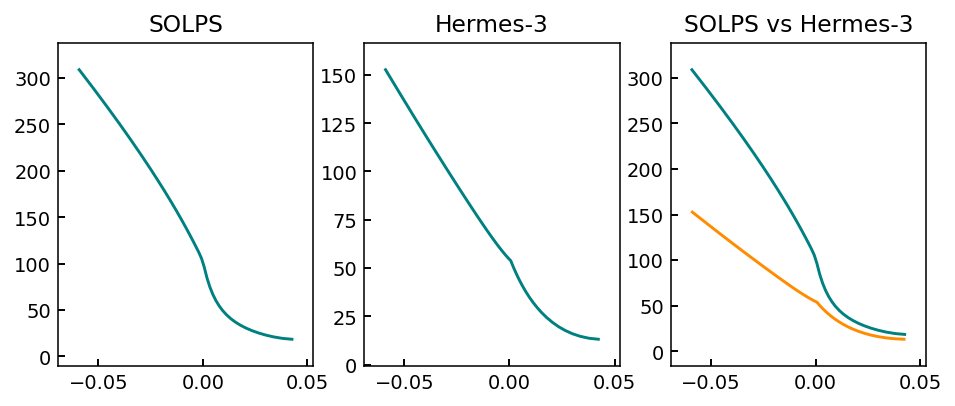

In [23]:

# list(bal.variables.keys())
# get_1d_radial_data is a pandas dataframe
df = bal.get_1d_radial_data(params=["Td+","Nd+","Pd+"], region="omp")
# display(df)

fig, ax = plt.subplots(1,3, figsize=(8,3))
ax[0].plot(df["dist"], df["Td+"])
ax[0].set_title("SOLPS")

## Hermes-3
ds = cs["nowallpump_1e21_limiterOFF"].ds.isel(t=-1)


df_hermes = get_1d_radial_data(ds, params = ["Td+"], region = "omp")
ax[1].plot(df_hermes["Srad"], df_hermes["Td+"])
ax[1].set_title("Hermes-3")

ax[2].plot(df["dist"], df["Td+"])
ax[2].plot(df_hermes["Srad"], df_hermes["Td+"])
ax[2].set_title("SOLPS vs Hermes-3")



Text(0.5, 1.0, 'SOLPS vs Hermes-3')

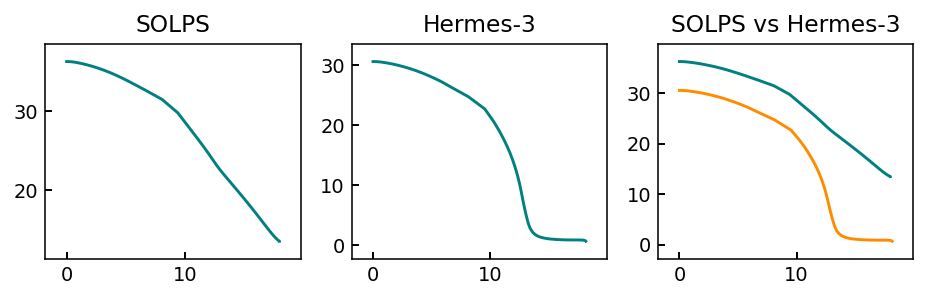

In [ ]:
df = bal.get_1d_poloidal_data(params=["Te","Ne","Pe"], region="outer_lower",sepadd=1)
# display(df)
qe = 1.6e-19

# print(f"Pe is {df["Te"][::-1]*df["Ne"][::-1]*qe}")
fig, ax = plt.subplots(1,3, figsize = (8, 2))
ax[0].plot(df["Spar"], df["Te"])
ax[0].set_title("SOLPS")
# # Hermes-3

ds = cs["nowallpump_1e21_limiterOFF"].ds.isel(t=-1)


df_hermes = get_1d_poloidal_data(ds, params = ["Te","Ne"], region = "outer_lower",sepadd =1 )

# print(f"Hermes-3 Pe is {df_hermes["Te"][::-1]*df_hermes["Ne"][::-1]*qe}")
ax[1].plot(df_hermes["Spar"], df_hermes["Te"])
ax[1].set_title("Hermes-3")

ax[2].plot(df["Spar"], df["Te"])
ax[2].plot(df_hermes["Spar"], df_hermes["Te"])
ax[2].set_title("SOLPS vs Hermes-3")

## Plot 2D polygon

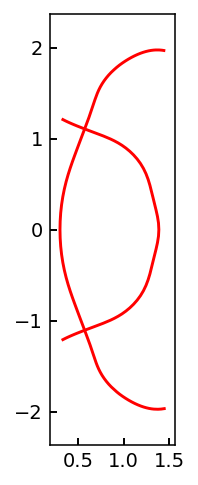

In [25]:
# Plot separatrix of SOLPS
fig, ax = plt.subplots()
bal.plot_separatrix(ax=ax, ls = "-", c="red")
ax.set_aspect('equal', adjustable='box')


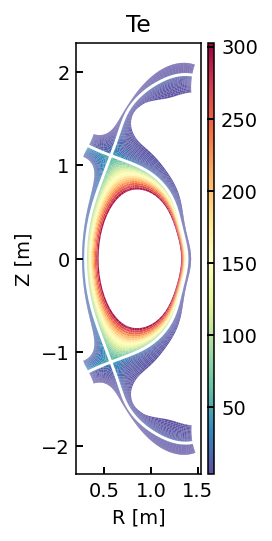

In [ ]:
fig, ax = plt.subplots()

bal.plot_2d(ax=ax, param="Te")

ax.set_aspect('equal', adjustable='box')


# Fort.44 variables
(Below are things done in UKAEA visiting to check the neutral flux)

In [19]:
# Extract pfluxa from fort.44 and pad to (nx, ny)
import numpy as np
import builtins

filename = "solps_files/fort.44"
var_name = "pfluxa"
with builtins.open(filename, 'r') as f:
    lines = f.readlines()

data_lines = []
found = False
for line in lines:
    if line.startswith(f"*eirene data field {var_name}"):
        found = True
        continue
    if found:
        if line.startswith("*"):
            break
        data_lines.append(line)

data = []
for line in data_lines:
    data.extend([float(x) for x in line.split()])

pfluxa = np.array(data)
print(f"Raw pfluxa (an array): {pfluxa}")

# Number of cells in balance.nc
nx, ny = bal.g["nx"], bal.g["ny"]
print(f"pfluxa size = {pfluxa.size}, nx = {nx}, ny = {ny}, nx*ny = {nx*ny}")
# print(f"Shape of pfluxa from fort.44: {np.shape(pfluxa)}")

# fort.44 outputs without guard cells: shape is (nx-2, ny-2)
# Fortran order ('F') means first dimension (poloidal) varies fastest.
pfluxa_inner = pfluxa.reshape((nx-2, ny-2), order='F')
print(f"pfluxa_inner: {pfluxa_inner}")


# Pad with zeros to match SOLPS grid shape (nx, ny)
pfluxa_padded = np.zeros((nx, ny))
pfluxa_padded[1:-1, 1:-1] = pfluxa_inner
print(pfluxa_padded)



# Plot using bal's plot_2d
# We need to flatten it since SOLPScase plot_2d expects a flattened array or internal data
try:
    # plot_2d uses the parameter as a title, and data for the values if provided
    bal.plot_2d(var_name, data=pfluxa_padded, logscale=True, cmap="plasma")
except Exception as e:
    print(f"Error plotting: {e}")

# --- Velocity Calculation ---
# Get Neutral Density from your SOLPScase (shape is already nx, ny)
Nd = bal.bal["Nd"]
# Do a safe division: Vd = pfluxa / Nd (outputs 0 where Nd is 0)
Vd = np.divide(pfluxa_padded, Nd, out=np.zeros_like(pfluxa_padded), where=(Nd!=0))
# Plot the new velocity array!
bal.plot_2d("Vd", data=Vd, logscale=True,vmin= - 1e5, vmax=1e5)

FileNotFoundError: [Errno 2] No such file or directory: 'solps_files/fort.44'

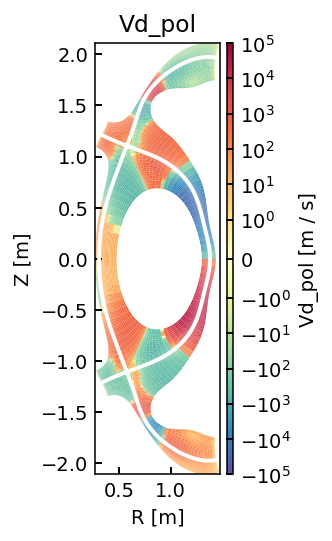

In [21]:
fig, ax = plt.subplots()
ds = cs["neutralimit_gcc12_9497476"].ds.isel(t=-1)
ds["Vd_pol"]=ds["Vd"]*abs(ds["Bpxy"] / abs(ds["Bxy"]))
ds["Vd_pol"].bout.polygon(ax = ax , cmap = "Spectral_r", antialias = True,logscale = True ,vmin= - 1e5, vmax=1e5)

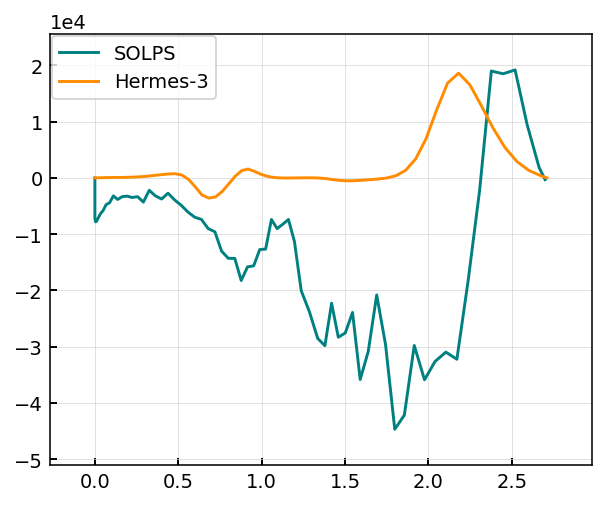

In [9]:
bal.bal["pfluxa"] = pfluxa_padded
# SOLPS
dsolps = bal.get_1d_poloidal_data(params=["Nd","pfluxa"], region="outer_lower", sepadd=1, target_first=1)
dsolps["Vd"]=dsolps["pfluxa"]/dsolps["Nd"]

# Hermes-3
ds = cs["neutralimit_gcc12_9497476"].ds.isel(t=-1)
dhermes = get_1d_poloidal_data(ds, params=["Nd", "Vd","Bpxy","Bxy"], region="outer_lower", sepadd=1, target_first=1)
dhermes["Vd_pol"]=dhermes["Vd"]*abs(dhermes["Bpxy"] / abs(dhermes["Bxy"]))

fig, ax = plt.subplots()
ax.plot(dsolps["Spol"], dsolps["Vd"], label="SOLPS")
ax.plot(dhermes["Spol"], dhermes["Vd_pol"], label="Hermes-3")
ax.legend()
ax.grid(alpha=0.7)
plt.show()

# Compare between SOLPS files

- SOLPS_limiter_off: electron conduction limiter  

- SOLPS_Luciani_off: electron conduction limiter off and Luciani off


In [4]:
from pltool.common import  adapt_solps_conventions

setup_matplotlib()

# Returns a dict {name: SOLPScase} when more than one id is given
def read_solps_balance(input_id=None):
    """Read one or more SOLPS balance files.

    input_id : str or list of str, keys of SOLPS_CASES. None -> all cases.
    Returns a single SOLPScase for one id, else a dict {name: SOLPScase}.
    """
    root = "/Users/zero/workspace/phd_work/hms_output"

    # SOLPScase init appends "balance.nc", so only the folder is required
    SOLPS_CASES = {
        "1e21":         os.path.join(root, "SOLPS_Luciani_off"),
        "cx100_1e21":         os.path.join(root, "SOLPS_Luciani_off_cx100"),
        "cx100_1e22":         os.path.join(root, "SOLPS_Luciani_off_cx100_1e22"),
    }
    # print(os.path.join(root, "SOLPS_Luciani_off"))
    # print(os.path.join(root, "SOLPS_limiter_off"))
    if input_id is None:
        ids = list(SOLPS_CASES)
    elif isinstance(input_id, str):
        ids = [input_id]
    else:
        ids = list(input_id)

    for i in ids:
        if i not in SOLPS_CASES:
            raise KeyError(f"Unknown SOLPS id '{i}', choose from {list(SOLPS_CASES)}")

    bals = {i: SOLPScase(SOLPS_CASES[i]) for i in ids}

    return bals[ids[0]] if len(ids) == 1 else bals
bals = read_solps_balance(["1e21", "cx100_1e21", "cx100_1e22"])

# adapt_solps_conventions takes a single case, so map it over the dict
bals = {k: adapt_solps_conventions(v) for k, v in bals.items()}

print(list(bals))


['1e21', 'cx100_1e21', 'cx100_1e22']


### Radial comparison

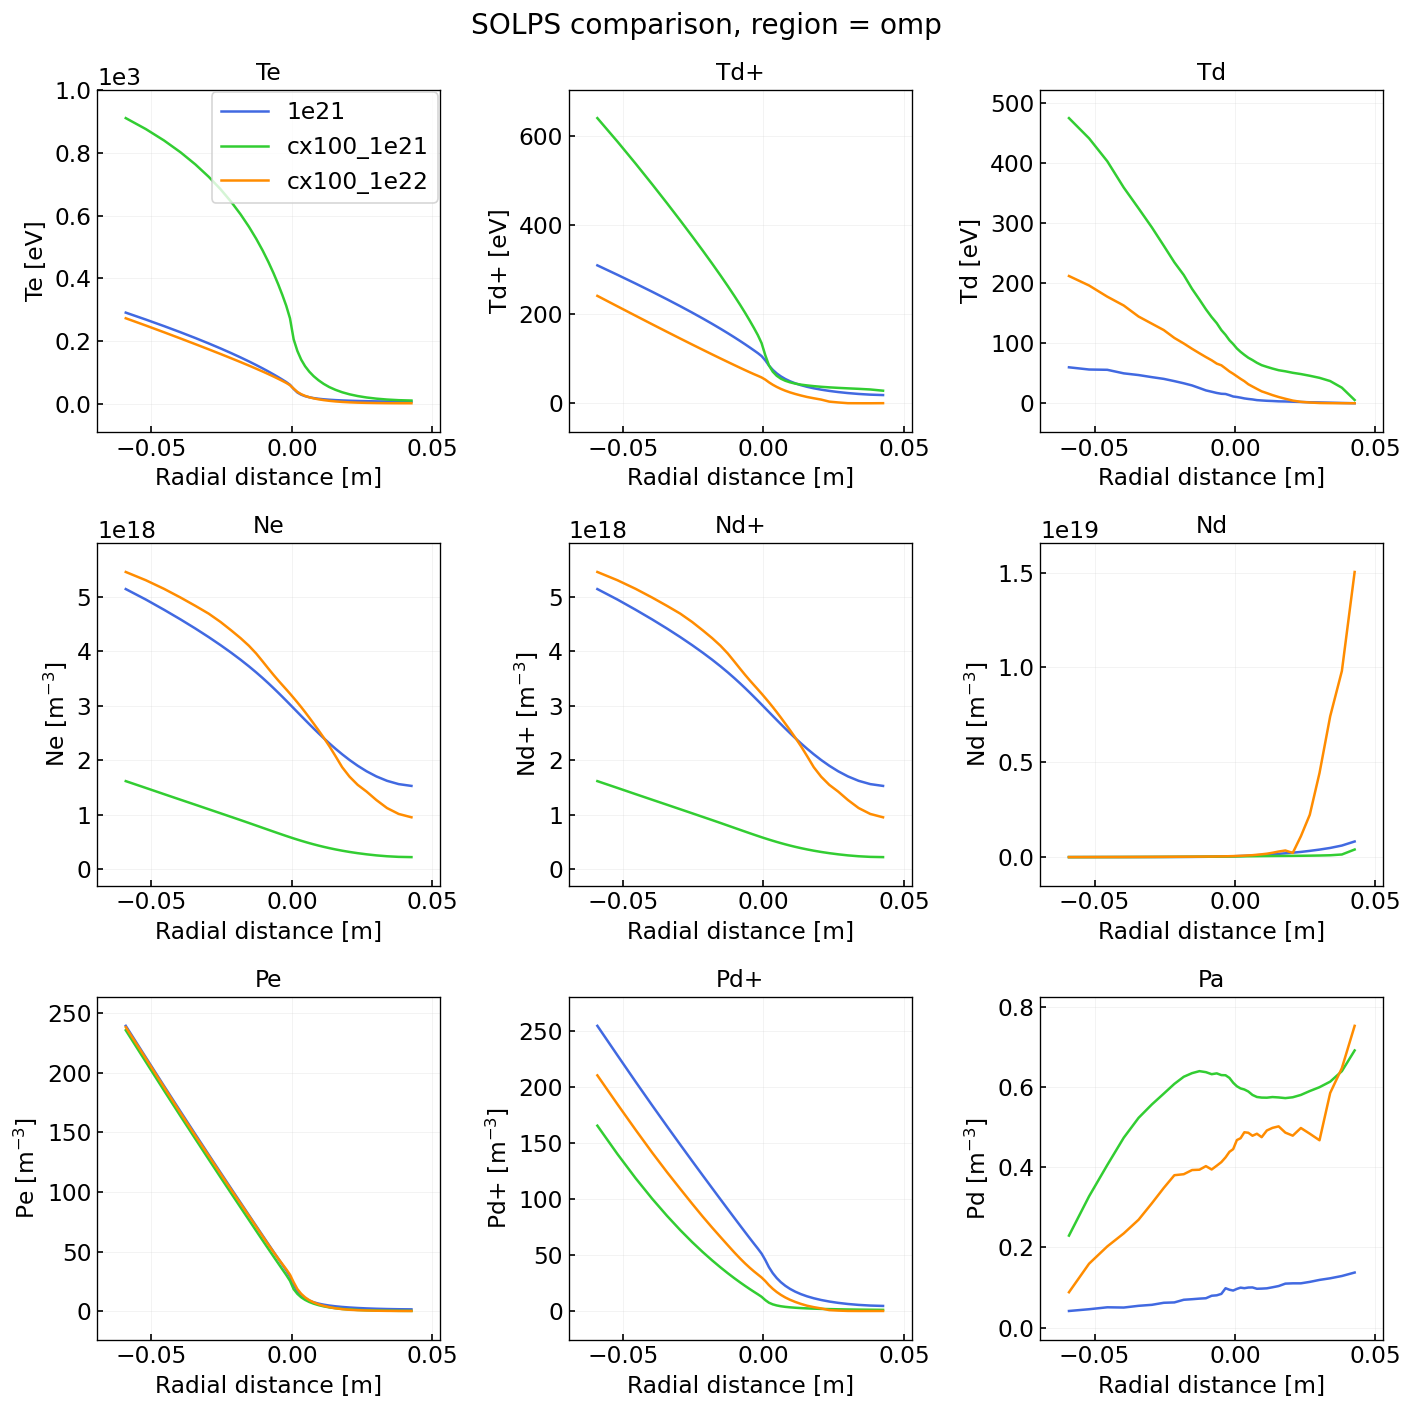

In [5]:
region_rad = "omp"

params_rad = [
    ("Te",  "Te [eV]"),
    ("Td+", "Td+ [eV]"),
    ("Td",  "Td [eV]"),
    ("Ne",  "Ne [m$^{-3}$]"),
    ("Nd+", "Nd+ [m$^{-3}$]"),
    ("Nd",  "Nd [m$^{-3}$]"),
    ("Pe",  "Pe [m$^{-3}$]"),
    ("Pd+", "Pd+ [m$^{-3}$]"),
    ("Pa",  "Pd [m$^{-3}$]"),
]

cols = 3
rows = int(np.ceil(len(params_rad) / cols))          # np already imported; no math needed
fig, ax = plt.subplots(rows, cols, figsize=(12, 4 * rows), squeeze=False)
axs = ax.flatten()                                    # 1-D list of axes to zip over

# one line per SOLPS case, one subplot per variable
for name, b in bals.items():
    df = b.get_1d_radial_data(params=[p for p, _ in params_rad], region=region_rad)
    for axi, (p, _) in zip(axs, params_rad):
        axi.plot(df["dist"], np.abs(df[p]), label=name)

# format each used panel
for axi, (p, ylabel) in zip(axs, params_rad):
    axi.set_xlabel("Radial distance [m]")
    axi.set_ylabel(ylabel)
    axi.set_title(p)
    axi.grid(alpha=0.3)

# hide any leftover empty panels
for axi in axs[len(params_rad):]:
    axi.axis("off")

axs[0].legend()
fig.suptitle(f"SOLPS comparison, region = {region_rad}")
fig.tight_layout()


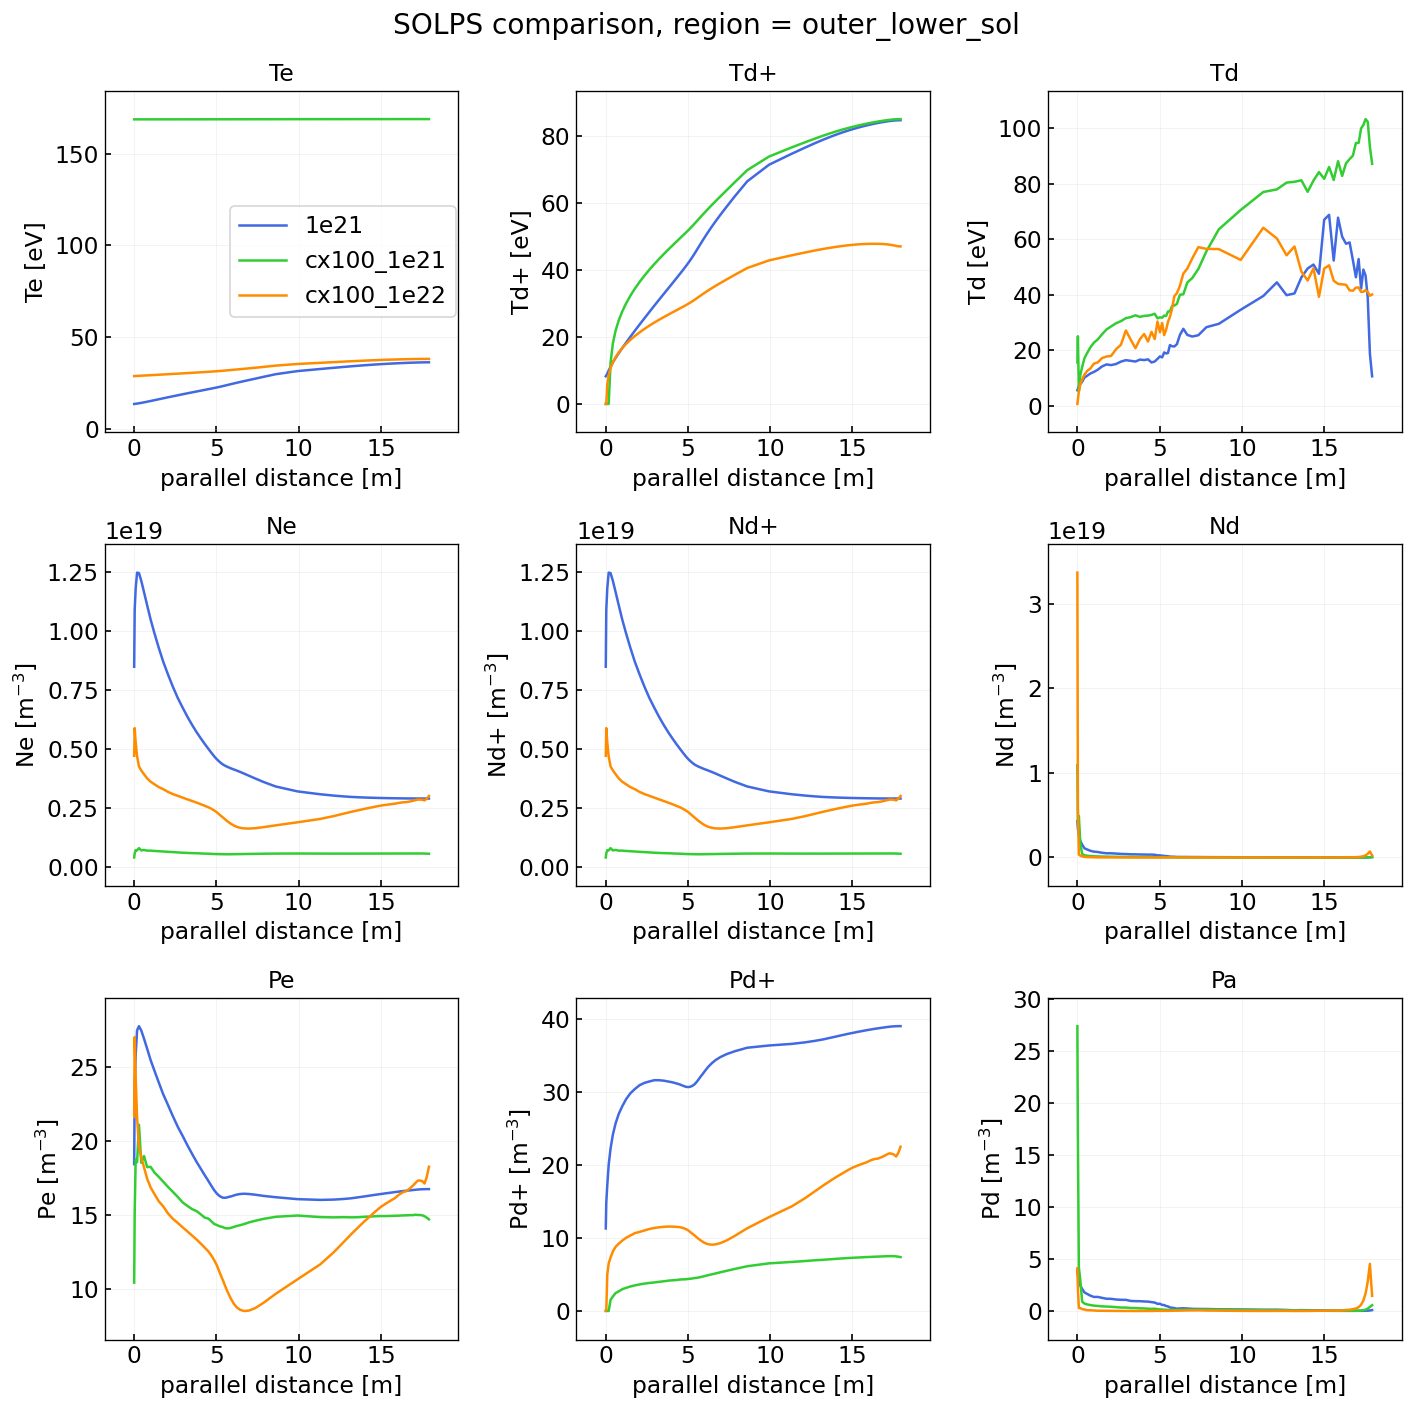

In [6]:
region_parallel = "outer_lower_sol"

params_parallel = [
    ("Te",  "Te [eV]"),
    ("Td+", "Td+ [eV]"),
    ("Td",  "Td [eV]"),
    ("Ne",  "Ne [m$^{-3}$]"),
    ("Nd+", "Nd+ [m$^{-3}$]"),
    ("Nd",  "Nd [m$^{-3}$]"),
    ("Pe",  "Pe [m$^{-3}$]"),
    ("Pd+", "Pd+ [m$^{-3}$]"),
    ("Pa",  "Pd [m$^{-3}$]"),
]

cols = 3
rows = int(np.ceil(len(params_parallel) / cols))          # np already imported; no math needed
fig, ax = plt.subplots(rows, cols, figsize=(12, 4 * rows), squeeze=False)
axs = ax.flatten()                                    # 1-D list of axes to zip over

# one line per SOLPS case, one subplot per variable
for name, b in bals.items():
    df = b.get_1d_poloidal_data(params=[p for p, _ in params_parallel], sepadd=1, region=region_parallel,target_first=True, interpolate_midplane=False, interpolate_radial=False )
    for axi, (p, _) in zip(axs, params_parallel):
        axi.plot(df["Spar"], np.abs(df[p]), label=name)

# format each used panel
for axi, (p, ylabel) in zip(axs, params_parallel):
    axi.set_xlabel("parallel distance [m]")
    axi.set_ylabel(ylabel)
    axi.set_title(p)
    axi.grid(alpha=0.3)

# hide any leftover empty panels
for axi in axs[len(params_parallel):]:
    axi.axis("off")

axs[0].legend()
fig.suptitle(f"SOLPS comparison, region = {region_parallel}")
fig.tight_layout()

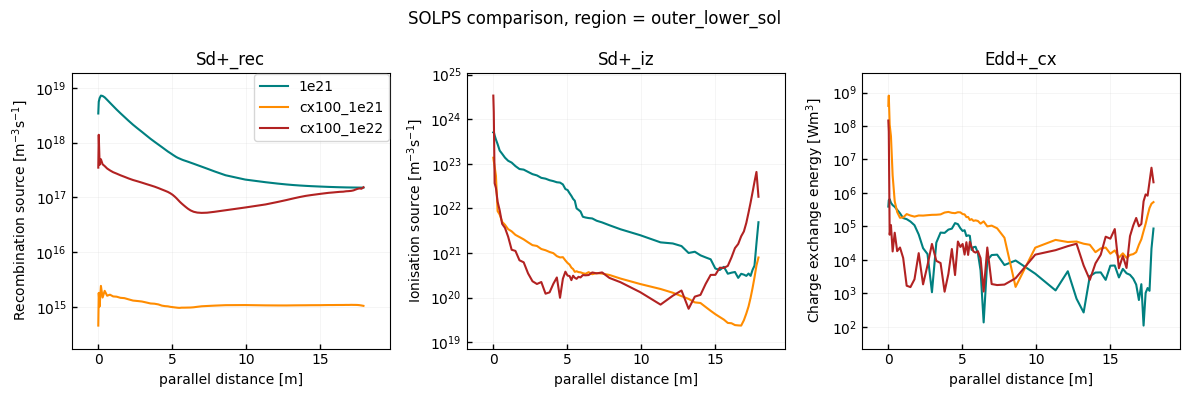

In [6]:
region_parallel = "outer_lower_sol"

params_parallel = [
            ("Sd+_rec", "Recombination source [$m^{-3} s^{-1}$]"),
            ("Sd+_iz",  "Ionisation source [$m^{-3} s^{-1}$]"),
            ("Edd+_cx", "Charge exchange energy [$W m^{3}$]"),
]

cols = 3
rows = int(np.ceil(len(params_parallel) / cols))          # np already imported; no math needed
fig, ax = plt.subplots(rows, cols, figsize=(12, 4 * rows), squeeze=False)
axs = ax.flatten()                                    # 1-D list of axes to zip over

# one line per SOLPS case, one subplot per variable
for name, b in bals.items():
    df = b.get_1d_poloidal_data(params=[p for p, _ in params_parallel], sepadd=1, region=region_parallel,target_first=True, interpolate_midplane=False, interpolate_radial=False )
    for axi, (p, _) in zip(axs, params_parallel):
        axi.plot(df["Spar"], np.abs(df[p]), label=name)

# format each used panel
for axi, (p, ylabel) in zip(axs, params_parallel):
    axi.set_xlabel("parallel distance [m]")
    axi.set_ylabel(ylabel)
    axi.set_title(p)
    axi.grid(alpha=0.3)
    axi.set_yscale("symlog")

# hide any leftover empty panels
for axi in axs[len(params_parallel):]:
    axi.axis("off")

axs[0].legend()
fig.suptitle(f"SOLPS comparison, region = {region_parallel}")
fig.tight_layout()

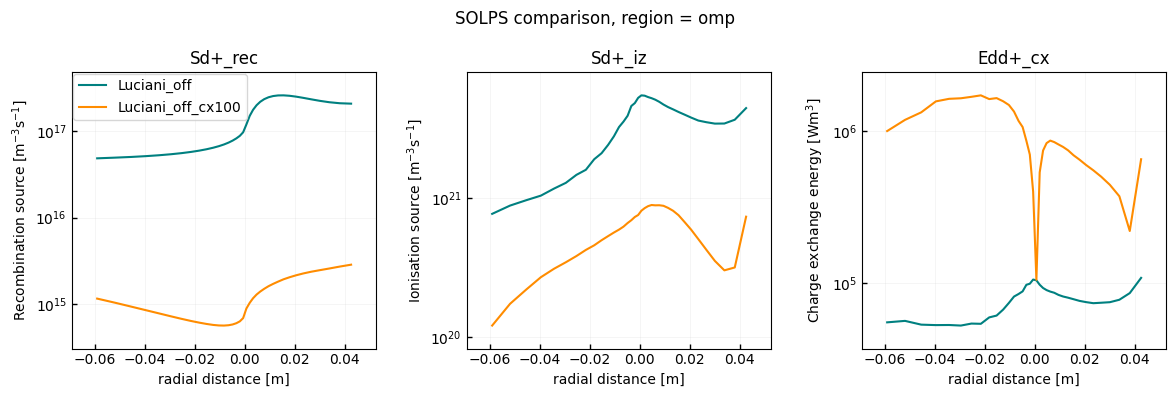

In [55]:
region_radial = "omp"

params_radial = [
            ("Sd+_rec", "Recombination source [$m^{-3} s^{-1}$]"),
            ("Sd+_iz",  "Ionisation source [$m^{-3} s^{-1}$]"),
            ("Edd+_cx", "Charge exchange energy [$W m^{3}$]"),
]

cols = 3
rows = int(np.ceil(len(params_radial) / cols))          # np already imported; no math needed
fig, ax = plt.subplots(rows, cols, figsize=(12, 4 * rows), squeeze=False)
axs = ax.flatten()                                    # 1-D list of axes to zip over

# one line per SOLPS case, one subplot per variable
for name, b in bals.items():
    df = b.get_1d_radial_data(params=[p for p, _ in params_radial],  region=region_radial )
    for axi, (p, _) in zip(axs, params_radial):
        axi.plot(df["dist"], np.abs(df[p]), label=name)

# format each used panel
for axi, (p, ylabel) in zip(axs, params_radial):
    axi.set_xlabel("radial distance [m]")
    axi.set_ylabel(ylabel)
    axi.set_title(p)
    axi.grid(alpha=0.3)
    axi.set_yscale("symlog")

# hide any leftover empty panels
for axi in axs[len(params_radial):]:
    axi.axis("off")

axs[0].legend()
fig.suptitle(f"SOLPS comparison, region = {region_radial}")
fig.tight_layout()